# Load Dataset


In [1]:
#importing/memasukkan package untuk alat bantu memproses data
import pandas as pd
import numpy as np
from scipy.stats import stats
import seaborn as sns
import warnings 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
warnings.simplefilter(action='ignore',category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option('display.max_columns',50)

# Membaca dan menampilkan dataset yang akan diproses
df = pd.read_csv(r'C:\Users\ASUS\Downloads\latihan Netflix\events.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


# Data Inspection

## Lookout data shape, info, types, etc.

In [2]:
df.shape

(885129, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [4]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,product_id,category_id,price,user_id
count,885129.00,885129.00,885129.00,885129.00
mean,1906620.54,2144422967987037184.00,146.33,1515915625558965504.00
std,1458708.10,616510516083801.25,296.81,37472865.57
min,102.00,2144415921001725952.00,0.22,1515915625353227008.00
25%,698803.00,2144415922528452608.00,26.46,1515915625533004288.00
50%,1452883.00,2144415925011480832.00,65.71,1515915625554085376.00
75%,3721194.00,2144415927519674624.00,190.49,1515915625594517504.00
max,4183880.00,2227847332769039360.00,64771.06,1515915625611024128.00


In [5]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['product_id', 'category_id', 'price', 'user_id'], dtype='object')
Categorical columns: Index(['event_time', 'event_type', 'category_code', 'brand', 'user_session'], dtype='object')


Data type needs to be altered. Most of the numerical columns were numerical identifier, and should not be used for calculation. 'Price' should stay as numerical. Product, category, user id should be changed into object or categorical.

# Checking for Inconsistency

In [6]:
pd.set_option('display.max_colwidth', None)
unique_summary = pd.DataFrame({
    'n_unique': df.nunique(),
    'unique_values': df.apply(lambda x: x.unique())
})

unique_summary

,n_unique,unique_values
event_time,845041,"[2020-09-24 11:57:06 UTC, 2020-09-24 11:57:26 UTC, 2020-09-24 11:57:27 UTC, 2020-09-24 11:57:33 UTC, 2020-09-24 11:57:36 UTC, 2020-09-24 11:57:59 UTC, 2020-09-24 11:58:23 UTC, 2020-09-24 11:58:24 UTC, 2020-09-24 11:58:25 UTC, 2020-09-24 11:58:31 UTC, 2020-09-24 11:58:34 UTC, 2020-09-24 11:58:54 UTC, 2020-09-24 11:59:26 UTC, 2020-09-24 12:00:00 UTC, 2020-09-24 12:00:01 UTC, 2020-09-24 12:00:10 UTC, 2020-09-24 12:00:16 UTC, 2020-09-24 12:00:33 UTC, 2020-09-24 12:00:36 UTC, 2020-09-24 12:00:37 UTC, 2020-09-24 12:00:39 UTC, 2020-09-24 12:00:53 UTC, 2020-09-24 12:00:57 UTC, 2020-09-24 12:00:59 UTC, 2020-09-24 12:01:01 UTC, 2020-09-24 12:01:07 UTC, 2020-09-24 12:01:11 UTC, 2020-09-24 12:01:13 UTC, 2020-09-24 12:01:18 UTC, 2020-09-24 12:01:33 UTC, 2020-09-24 12:01:37 UTC, 2020-09-24 12:02:12 UTC, 2020-09-24 12:02:19 UTC, 2020-09-24 12:02:34 UTC, 2020-09-24 12:02:39 UTC, 2020-09-24 12:02:44 UTC, 2020-09-24 12:02:53 UTC, 2020-09-24 12:02:54 UTC, 2020-09-24 12:02:58 UTC, 2020-09-24 12:03:01 UTC, 2020-09-24 12:03:12 UTC, 2020-09-24 12:03:17 UTC, 2020-09-24 12:03:37 UTC, 2020-09-24 12:04:10 UTC, 2020-09-24 12:04:15 UTC, 2020-09-24 12:05:06 UTC, 2020-09-24 12:05:17 UTC, 2020-09-24 12:05:19 UTC, 2020-09-24 12:05:46 UTC, 2020-09-24 12:06:34 UTC, 2020-09-24 12:06:37 UTC, 2020-09-24 12:06:48 UTC, 2020-09-24 12:07:08 UTC, 2020-09-24 12:07:26 UTC, 2020-09-24 12:07:35 UTC, 2020-09-24 12:07:55 UTC, 2020-09-24 12:08:21 UTC, 2020-09-24 12:08:24 UTC, 2020-09-24 12:08:41 UTC, 2020-09-24 12:08:46 UTC, 2020-09-24 12:09:33 UTC, 2020-09-24 12:10:10 UTC, 2020-09-24 12:10:45 UTC, 2020-09-24 12:10:51 UTC, 2020-09-24 12:10:55 UTC, 2020-09-24 12:11:17 UTC, 2020-09-24 12:11:23 UTC, 2020-09-24 12:11:43 UTC, 2020-09-24 12:12:06 UTC, 2020-09-24 12:12:16 UTC, 2020-09-24 12:12:24 UTC, 2020-09-24 12:12:33 UTC, 2020-09-24 12:12:41 UTC, 2020-09-24 12:13:03 UTC, 2020-09-24 12:13:05 UTC, 2020-09-24 12:14:01 UTC, 2020-09-24 12:14:07 UTC, 2020-09-24 12:14:13 UTC, 2020-09-24 12:14:48 UTC, 2020-09-24 12:15:03 UTC, 2020-09-24 12:15:06 UTC, 2020-09-24 12:15:11 UTC, 2020-09-24 12:15:16 UTC, 2020-09-24 12:15:29 UTC, 2020-09-24 12:15:55 UTC, 2020-09-24 12:16:10 UTC, 2020-09-24 12:16:18 UTC, 2020-09-24 12:16:28 UTC, 2020-09-24 12:16:41 UTC, 2020-09-24 12:16:47 UTC, 2020-09-24 12:16:48 UTC, 2020-09-24 12:17:29 UTC, 2020-09-24 12:17:51 UTC, 2020-09-24 12:18:01 UTC, 2020-09-24 12:18:09 UTC, 2020-09-24 12:18:27 UTC, 2020-09-24 12:18:48 UTC, 2020-09-24 12:18:49 UTC, 2020-09-24 12:19:01 UTC, 2020-09-24 12:19:52 UTC, ...]"
event_type,3,"[view, cart, purchase]"
product_id,53453,"[1996170, 139905, 215454, 635807, 3658723, 664325, 3791349, 716611, 657859, 811491, 337116, 1080093, 1455459, 3537266, 3830537, 523117, 3830671, 10914, 1021484, 1926, 1642942, 3829275, 315366, 1356542, 144417, 3506345, 1399998, 888783, 261923, 3828758, 1507291, 3536864, 347850, 758525, 136700, 3661285, 481930, 4101820, 3149184, 3791351, 677289, 1417423, 661128, 13327, 740421, 748877, 1784819, 1271563, 266369, 1745481, 589450, 1444773, 666781, 822426, 1355041, 1667761, 857015, 1283197, 315364, 90232, 1400817, 898068, 1829859, 627054, 1503903, 4060928, 659849, 251001, 1263516, 4154001, 1413341, 933650, 908134, 52708, 4005472, 1651978, 4172850, 1505227, 221094, 860100, 3573412, 1354265, 3791538, 788109, 620415, 4155372, 1504974, 1271549, 651503, 1111627, 809948, 1569901, 1976006, 3698755, 3830144, 459699, 665981, 4171262, 1505265, 1299774, ...]"
category_id,718,"[2144415922528452715, 2144415926932472027, 2144415927158964449, 2144415923107266682, 2144415921169498184, 2144415951611757447, 2144415935086199225, 2144415923694469257, 2144415939431498289, 2144415926370435276, 2144415921505042512, 2144415927049912542, 2144415923207929981, 2144415924491387038, 2144415929440665888, 2144415925053423789, 2144415944976368325, 2144415948256314150, 2144415924382335131, 2144415927553229037, 2144415923535085701, 2144415922167742561, 2144415922939494519, 2144415975410238005, 21444159268066429

Category code could be segmented into main category, and sub category

# Check for Missing & Duplicated Value

In [7]:
missing = df.isnull().sum()
missing[missing > 0]

category_code    236219
brand            212364
user_session        165
dtype: int64

In [8]:
df_us_nan = df[df['user_session'].isnull()]

In [9]:

unique_summary = pd.DataFrame({
    'n_unique': df_us_nan.nunique(),
    'unique_values': df_us_nan.apply(lambda x: x.unique())
})

unique_summary

,n_unique,unique_values
event_time,162,"[2020-09-24 23:47:04 UTC, 2020-09-26 05:14:39 UTC, 2020-09-26 10:58:24 UTC, 2020-09-27 11:59:41 UTC, 2020-09-30 07:31:01 UTC, 2020-10-01 04:39:58 UTC, 2020-10-01 09:41:32 UTC, 2020-10-01 22:17:58 UTC, 2020-10-02 17:44:26 UTC, 2020-10-05 13:45:35 UTC, 2020-10-06 16:20:20 UTC, 2020-10-07 11:18:15 UTC, 2020-10-07 17:52:38 UTC, 2020-10-08 08:29:02 UTC, 2020-10-09 08:16:02 UTC, 2020-10-09 13:15:56 UTC, 2020-10-10 20:03:28 UTC, 2020-10-11 18:53:03 UTC, 2020-10-15 03:34:53 UTC, 2020-10-15 08:14:01 UTC, 2020-10-19 09:08:37 UTC, 2020-10-19 12:49:44 UTC, 2020-10-21 03:15:40 UTC, 2020-10-21 19:03:26 UTC, 2020-10-21 22:37:09 UTC, 2020-10-24 15:00:56 UTC, 2020-10-24 17:57:44 UTC, 2020-10-25 18:07:48 UTC, 2020-10-26 19:13:20 UTC, 2020-10-27 20:03:00 UTC, 2020-10-28 03:15:52 UTC, 2020-10-28 05:59:20 UTC, 2020-10-30 06:20:40 UTC, 2020-10-30 11:52:19 UTC, 2020-11-01 13:03:38 UTC, 2020-11-02 21:15:59 UTC, 2020-11-02 21:17:15 UTC, 2020-11-02 21:17:32 UTC, 2020-11-03 04:05:35 UTC, 2020-11-03 13:53:02 UTC, 2020-11-04 10:25:38 UTC, 2020-11-04 13:58:06 UTC, 2020-11-04 16:22:35 UTC, 2020-11-04 17:17:10 UTC, 2020-11-04 17:17:11 UTC, 2020-11-05 17:52:05 UTC, 2020-11-06 10:26:41 UTC, 2020-11-07 09:51:00 UTC, 2020-11-07 14:21:18 UTC, 2020-11-07 21:34:30 UTC, 2020-11-08 20:31:43 UTC, 2020-11-10 06:03:18 UTC, 2020-11-10 21:09:11 UTC, 2020-11-11 11:30:01 UTC, 2020-11-11 15:20:24 UTC, 2020-11-11 21:45:26 UTC, 2020-11-13 17:21:15 UTC, 2020-11-14 18:21:53 UTC, 2020-11-15 08:05:24 UTC, 2020-11-17 10:39:58 UTC, 2020-11-17 14:50:32 UTC, 2020-11-18 19:57:03 UTC, 2020-11-19 22:55:07 UTC, 2020-11-20 06:55:15 UTC, 2020-11-21 04:23:48 UTC, 2020-11-21 13:21:53 UTC, 2020-11-22 03:01:11 UTC, 2020-11-22 15:03:52 UTC, 2020-11-23 12:50:35 UTC, 2020-11-24 13:41:20 UTC, 2020-11-24 13:42:41 UTC, 2020-11-24 13:48:03 UTC, 2020-11-24 13:48:19 UTC, 2020-11-24 16:57:12 UTC, 2020-11-25 07:07:29 UTC, 2020-11-25 17:42:49 UTC, 2020-11-25 17:47:21 UTC, 2020-11-25 17:49:27 UTC, 2020-11-25 19:53:40 UTC, 2020-11-26 06:50:51 UTC, 2020-11-26 07:32:17 UTC, 2020-11-27 07:57:06 UTC, 2020-11-27 15:10:19 UTC, 2020-11-28 21:27:20 UTC, 2020-11-28 21:28:00 UTC, 2020-11-29 17:58:15 UTC, 2020-11-30 09:31:22 UTC, 2020-11-30 10:36:28 UTC, 2020-12-01 09:42:10 UTC, 2020-12-02 04:58:07 UTC, 2020-12-02 17:08:53 UTC, 2020-12-03 08:22:26 UTC, 2020-12-03 17:28:57 UTC, 2020-12-04 10:52:50 UTC, 2020-12-05 07:11:38 UTC, 2020-12-05 08:25:19 UTC, 2020-12-06 14:40:16 UTC, 2020-12-06 14:41:10 UTC, 2020-12-06 18:47:39 UTC, 2020-12-07 06:50:10 UTC, ...]"
event_type,2,"[view, cart]"
product_id,142,"[1715896, 3791351, 1785245, 1153724, 1559260, 1423208, 790766, 261923, 933650, 4183797, 1079687, 3556526, 1723928, 775167, 1355071, 846632, 4078376, 895100, 635062, 1467320, 2278498, 1814282, 606783, 1283112, 3829572, 1030457, 474437, 1795842, 295680, 611820, 3721094, 908538, 4032376, 4078422, 629218, 4154733, 3656510, 3793178, 1723786, 546007, 912376, 1354440, 780741, 454794, 476068, 888538, 1666708, 886914, 4154755, 600280, 4044497, 498514, 1031484, 1821557, 4101436, 1614100, 1578364, 584322, 1167923, 3660172, 1042420, 3671624, 242842, 1444915, 3735084, 1149652, 802440, 1829784, 4101820, 847643, 502285, 777970, 787686, 337631, 194199, 736587, 332646, 3829570, 1694260, 1466909, 193859, 3830564, 4079061, 4170539, 1830166, 4100017, 716543, 564832, 1045039, 1549867, 911921, 3791551, 1633490, 4170512, 3791693, 1821813, 126757, 1412241, 574576, 4183864, ...]"
category_id,89,"[2144415926731145430, 2144415926966026460, 2144415925011480748, 2144415921169498184, 2144415928845074703, 2144415922285183076, 2144415927158964449, 2144415922939494519, 2144415922092245087, 2144415939364389423, 2144415945890726624, 2144415923744800906, 2144415944523383481, 2144415924751433893, 2144415927913939190, 2144415929230950682, 2144415921253384266, 2144415935329468864, 2144415929197396249, 2144415973346640379, 2144415925196030129, 2144415922402623591, 2144415928618582281, 2144415924021624977, 2144415926060056772,

In [10]:
print(df.duplicated().sum())

655


In [11]:
df[df.duplicated(keep=False)]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
511,2020-09-24 13:51:07 UTC,view,387956,2144415922427789416,computers.components.videocards,asus,104.21,1515915625519429853,PZu2caZ5EN
512,2020-09-24 13:51:07 UTC,view,387956,2144415922427789416,computers.components.videocards,asus,104.21,1515915625519429853,PZu2caZ5EN
974,2020-09-24 15:48:55 UTC,view,874667,2144415922738167921,computers.components.cdrw,asus,23.48,1515915625519457150,8wvs0vbHtv
975,2020-09-24 15:48:55 UTC,view,874667,2144415922738167921,computers.components.cdrw,asus,23.48,1515915625519457150,8wvs0vbHtv
4827,2020-09-25 13:15:09 UTC,view,453469,2144415924222951574,auto.accessories.parktronic,NaN,69.84,1515915625519725870,9ofICyh8Eo
...,...,...,...,...,...,...,...,...,...
878751,2021-02-27 17:56:05 UTC,view,1571204,2144415924491387038,computers.components.motherboard,asus,146.40,1515915625610505518,EUqy2lyCvY
879544,2021-02-27 20:54:20 UTC,view,1027953,2144415923837075596,electronics.audio.acoustic,jbl,332.87,1515915625529755153,3mD3HIQ017
879545,2021-02-27 20:54:20 UTC,view,1027953,2144415923837075596,electronics.audio.acoustic,jbl,332.87,1515915625529755153,3mD3HIQ017
882715,2021-02-28 14:18:02 UTC,view,4078916,2144415922427789416,computers.components.videocards,sapphire,415.54,1515915625610828170,21hX1rWtum


In [12]:
df.groupby('category_id')['category_code'].nunique().sort_values()

category_id
2144415921001726020    0
2144415959044063321    0
2144415959111172187    0
2144415959178281053    0
2144415959220224094    0
                      ..
2144415935916671441    1
2144415935874728400    1
2144415935841173967    1
2144415936252215770    1
2227847332769039290    1
Name: category_code, Length: 718, dtype: int64

In [13]:
df.groupby('category_id')['category_code'].nunique().reset_index().sort_values('category_code', ascending=False)

,category_id,category_code
717,2227847332769039290,1
501,2144415949279724357,1
208,2144415929943982381,1
207,2144415929902039340,1
383,2144415939683156536,1
...,...,...
292,2144415934549328298,0
291,2144415934524162473,0
290,2144415934490608040,0
289,2144415934457053607,0


In [14]:
df.groupby('category_code')['category_id'].nunique().reset_index().sort_values('category_id', ascending=False)

,category_code,category_id
88,electronics.telephone,31
87,electronics.tablet,19
51,computers.notebook,13
77,electronics.audio.acoustic,8
58,computers.peripherals.printer,8
...,...,...
73,country_yard.cultivator,1
76,country_yard.weather_station,1
41,computers.components.motherboard,1
78,electronics.audio.dictaphone,1


In [15]:
df.groupby('category_id')['category_code'].agg([
    ('n_rows', 'size'),
    ('n_unique_codes', lambda x: x.nunique()),
    ('example_code', lambda x: x.dropna().iloc[0] if x.notna().any() else None)
]).sort_values('n_unique_codes', ascending=False)

,n_rows,n_unique_codes,example_code
category_id,,,
2227847332769039290,35,1,auto.accessories.light
2144415949279724357,390,1,construction.tools.wrench
2144415929943982381,2338,1,electronics.audio.microphone
2144415929902039340,898,1,appliances.personal.massager
2144415939683156536,214,1,sport.bicycle
...,...,...,...
2144415934549328298,7,0,None
2144415934524162473,77,0,None
2144415934490608040,3,0,None


In [16]:
df.loc[
    df['category_code'].str.contains('other', case=False, na=False),
    'category_code'
].unique()

array(['computers.components.motherboard'], dtype=object)

# Data Cleaning

## Convert data types

In [17]:
df['event_time'] = pd.to_datetime(df['event_time'])

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [18]:
convert_dict = {'product_id': str, 'category_id':str, 'user_id':str}

df = df.astype(convert_dict)
print(df.dtypes)

event_time       datetime64[ns, UTC]
event_type                    object
product_id                    object
category_id                   object
category_code                 object
brand                         object
price                        float64
user_id                       object
user_session                  object
dtype: object


## Handling Missing Values

In [19]:
df = df.dropna(subset=['user_session'])

In [20]:
missing = df.isnull().sum()
missing[missing > 0]

category_code    236172
brand            212326
dtype: int64

In [21]:
df['brand'].fillna('no brand', inplace=True)

In [22]:
df['brand'].value_counts(normalize=True,dropna=False)

brand
no brand    0.24
asus        0.03
gigabyte    0.03
msi         0.03
palit       0.03
            ... 
elekta      0.00
vitesse     0.00
vitek       0.00
docash      0.00
cipherlab   0.00
Name: proportion, Length: 1000, dtype: float64

In [23]:
df['category_code'].value_counts(normalize=True,dropna=False)

category_code
NaN                                0.27
computers.components.videocards    0.13
electronics.telephone              0.10
computers.peripherals.printer      0.05
stationery.cartrige                0.04
                                   ... 
furniture.bedroom.blanket          0.00
appliances.kitchen.refrigerators   0.00
furniture.kitchen.chair            0.00
accessories.briefcase              0.00
auto.accessories.winch             0.00
Name: proportion, Length: 108, dtype: float64

In [24]:
df['category_code'] = df['category_code'].fillna('uncategorized')

In [25]:
df['category_code'].value_counts(normalize=True,dropna=False)

category_code
uncategorized                      0.27
computers.components.videocards    0.13
electronics.telephone              0.10
computers.peripherals.printer      0.05
stationery.cartrige                0.04
                                   ... 
furniture.bedroom.blanket          0.00
appliances.kitchen.refrigerators   0.00
furniture.kitchen.chair            0.00
accessories.briefcase              0.00
auto.accessories.winch             0.00
Name: proportion, Length: 108, dtype: float64

In [26]:
df['category_code'] = df['category_code'].where(df['category_code'].notna(), None)
df['category_code']

0                 electronics.telephone
1           computers.components.cooler
2                         uncategorized
3         computers.peripherals.printer
4                         uncategorized
                      ...              
885124                    uncategorized
885125             electronics.video.tv
885126               electronics.clocks
885127            electronics.telephone
885128     construction.tools.soldering
Name: category_code, Length: 884964, dtype: object

## Divide categories

In [27]:
# Split into a maximum of 3 parts
split_cols = df['category_code'].str.split('.', n=2, expand=True)

# Rename and ensure the result has exactly 3 columns
split_cols.columns = ['category_main', 'category_sub', 'category_detail']

df = df.join(split_cols)
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_main,category_sub,category_detail
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,no brand,31.90,1515915625519388267,LJuJVLEjPT,electronics,telephone,None
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,computers,components,cooler
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,uncategorized,no brand,9.81,1515915625513238515,4TMArHtXQy,uncategorized,None,None
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,computers,peripherals,printer
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,uncategorized,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ,uncategorized,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...
885124,2021-02-28 23:55:01+00:00,view,953226,2144415927553229037,uncategorized,no brand,219.94,1515915625611023730,FRLqIttxKU,uncategorized,None,None
885125,2021-02-28 23:58:05+00:00,view,1715907,2144415927049912542,electronics.video.tv,starwind,80.03,1515915625611024014,g6WqPf50Ma,electronics,video,tv
885126,2021-02-28 23:58:09+00:00,view,4170534,2144415939364389423,electronics.clocks,amazfit,64.92,1515915625611024020,xNIJBqZdkd,electronics,clocks,None
885127,2021-02-28 23:58:14+00:00,view,888273,2144415921932861531,electronics.telephone,no brand,10.16,1515915625611024030,9pCbKMIcSx,electronics,telephone,None


In [28]:
df['category_main'].value_counts(normalize=True,dropna=False)

category_main
computers       0.36
uncategorized   0.27
electronics     0.19
stationery      0.05
appliances      0.05
auto            0.04
construction    0.04
furniture       0.00
country_yard    0.00
accessories     0.00
medicine        0.00
kids            0.00
jewelry         0.00
sport           0.00
apparel         0.00
Name: proportion, dtype: float64

In [29]:
df['category_sub'].value_counts(normalize=True,dropna=False)

category_sub
None              0.27
components        0.23
telephone         0.10
peripherals       0.09
cartrige          0.04
audio             0.04
accessories       0.04
tools             0.04
notebook          0.03
video             0.03
kitchen           0.02
tablet            0.02
environment       0.01
sewing_machine    0.01
desktop           0.01
clocks            0.00
ebooks            0.00
living_room       0.00
personal          0.00
cultivator        0.00
bag               0.00
paper             0.00
camera            0.00
network           0.00
battery           0.00
steam_cleaner     0.00
stapler           0.00
iron              0.00
fax               0.00
weather_station   0.00
lawn_mower        0.00
bicycle           0.00
souvenir          0.00
gaming            0.00
skates            0.00
toys              0.00
calculator        0.00
glove             0.00
watering          0.00
ring              0.00
bathroom          0.00
bedroom           0.00
briefcase         0.0

In [30]:
df['category_detail'].value_counts(normalize=True,dropna=False)

category_detail
None            0.49
videocards      0.13
printer         0.05
acoustic        0.03
motherboard     0.03
                ... 
chair           0.00
bath            0.00
blanket         0.00
refrigerators   0.00
winch           0.00
Name: proportion, Length: 78, dtype: float64

In [31]:
df_purchase = df[df['event_type']=='purchase']
df_purchase['category_main'].value_counts(normalize=True,dropna=False)

category_main
computers       0.45
uncategorized   0.20
electronics     0.18
stationery      0.08
auto            0.03
construction    0.03
appliances      0.02
furniture       0.00
accessories     0.00
country_yard    0.00
medicine        0.00
kids            0.00
sport           0.00
jewelry         0.00
Name: proportion, dtype: float64

In [32]:
df_purchase['category_sub'].value_counts(normalize=True,dropna=False)

category_sub
components        0.29
None              0.20
peripherals       0.12
telephone         0.11
cartrige          0.07
notebook          0.03
audio             0.03
accessories       0.03
tools             0.03
tablet            0.02
video             0.01
environment       0.01
kitchen           0.01
desktop           0.01
ebooks            0.01
sewing_machine    0.00
living_room       0.00
paper             0.00
camera            0.00
steam_cleaner     0.00
personal          0.00
stapler           0.00
bag               0.00
network           0.00
clocks            0.00
battery           0.00
calculator        0.00
toys              0.00
cultivator        0.00
weather_station   0.00
iron              0.00
lawn_mower        0.00
bicycle           0.00
souvenir          0.00
gaming            0.00
Name: proportion, dtype: float64

In [33]:
df_purchase['category_detail'].value_counts(normalize=True,dropna=False)

category_detail
None             0.47
videocards       0.18
printer          0.07
motherboard      0.03
cpu              0.03
                 ... 
juicer           0.00
immobilizer      0.00
toster           0.00
coffee_grinder   0.00
generator        0.00
Name: proportion, Length: 70, dtype: float64

In [34]:
unique_summary = pd.DataFrame({
    'n_unique': df.nunique(),
    'unique_values': df.apply(lambda x: x.unique())
})

unique_summary

,n_unique,unique_values
event_time,844899,"[2020-09-24 11:57:06+00:00, 2020-09-24 11:57:26+00:00, 2020-09-24 11:57:27+00:00, 2020-09-24 11:57:33+00:00, 2020-09-24 11:57:36+00:00, 2020-09-24 11:57:59+00:00, 2020-09-24 11:58:23+00:00, 2020-09-24 11:58:24+00:00, 2020-09-24 11:58:25+00:00, 2020-09-24 11:58:31+00:00, 2020-09-24 11:58:34+00:00, 2020-09-24 11:58:54+00:00, 2020-09-24 11:59:26+00:00, 2020-09-24 12:00:00+00:00, 2020-09-24 12:00:01+00:00, 2020-09-24 12:00:10+00:00, 2020-09-24 12:00:16+00:00, 2020-09-24 12:00:33+00:00, 2020-09-24 12:00:36+00:00, 2020-09-24 12:00:37+00:00, 2020-09-24 12:00:39+00:00, 2020-09-24 12:00:53+00:00, 2020-09-24 12:00:57+00:00, 2020-09-24 12:00:59+00:00, 2020-09-24 12:01:01+00:00, 2020-09-24 12:01:07+00:00, 2020-09-24 12:01:11+00:00, 2020-09-24 12:01:13+00:00, 2020-09-24 12:01:18+00:00, 2020-09-24 12:01:33+00:00, 2020-09-24 12:01:37+00:00, 2020-09-24 12:02:12+00:00, 2020-09-24 12:02:19+00:00, 2020-09-24 12:02:34+00:00, 2020-09-24 12:02:39+00:00, 2020-09-24 12:02:44+00:00, 2020-09-24 12:02:53+00:00, 2020-09-24 12:02:54+00:00, 2020-09-24 12:02:58+00:00, 2020-09-24 12:03:01+00:00, 2020-09-24 12:03:12+00:00, 2020-09-24 12:03:17+00:00, 2020-09-24 12:03:37+00:00, 2020-09-24 12:04:10+00:00, 2020-09-24 12:04:15+00:00, 2020-09-24 12:05:06+00:00, 2020-09-24 12:05:17+00:00, 2020-09-24 12:05:19+00:00, 2020-09-24 12:05:46+00:00, 2020-09-24 12:06:34+00:00, 2020-09-24 12:06:37+00:00, 2020-09-24 12:06:48+00:00, 2020-09-24 12:07:08+00:00, 2020-09-24 12:07:26+00:00, 2020-09-24 12:07:35+00:00, 2020-09-24 12:07:55+00:00, 2020-09-24 12:08:21+00:00, 2020-09-24 12:08:24+00:00, 2020-09-24 12:08:41+00:00, 2020-09-24 12:08:46+00:00, 2020-09-24 12:09:33+00:00, 2020-09-24 12:10:10+00:00, 2020-09-24 12:10:45+00:00, 2020-09-24 12:10:51+00:00, 2020-09-24 12:10:55+00:00, 2020-09-24 12:11:17+00:00, 2020-09-24 12:11:23+00:00, 2020-09-24 12:11:43+00:00, 2020-09-24 12:12:06+00:00, 2020-09-24 12:12:16+00:00, 2020-09-24 12:12:24+00:00, 2020-09-24 12:12:33+00:00, 2020-09-24 12:12:41+00:00, 2020-09-24 12:13:03+00:00, 2020-09-24 12:13:05+00:00, 2020-09-24 12:14:01+00:00, 2020-09-24 12:14:07+00:00, 2020-09-24 12:14:13+00:00, 2020-09-24 12:14:48+00:00, 2020-09-24 12:15:03+00:00, 2020-09-24 12:15:06+00:00, 2020-09-24 12:15:11+00:00, 2020-09-24 12:15:16+00:00, 2020-09-24 12:15:29+00:00, 2020-09-24 12:15:55+00:00, 2020-09-24 12:16:10+00:00, 2020-09-24 12:16:18+00:00, 2020-09-24 12:16:28+00:00, 2020-09-24 12:16:41+00:00, 2020-09-24 12:16:47+00:00, 2020-09-24 12:16:48+00:00, 2020-09-24 12:17:29+00:00, 2020-09-24 12:17:51+00:00, 2020-09-24 12:18:01+00:00, 2020-09-24 12:18:09+00:00, 2020-09-24 12:18:27+00:00, 2020-09-24 12:18:48+00:00, 2020-09-24 12:18:49+00:00, 2020-09-24 12:19:01+00:00, 2020-09-24 12:19:52+00:00, ...]"
event_type,3,"[view, cart, purchase]"
product_id,53452,"[1996170, 139905, 215454, 635807, 3658723, 664325, 3791349, 716611, 657859, 811491, 337116, 1080093, 1455459, 3537266, 3830537, 523117, 3830671, 10914, 1021484, 1926, 1642942, 3829275, 315366, 1356542, 144417, 3506345, 1399998, 888783, 261923, 3828758, 1507291, 3536864, 347850, 758525, 136700, 3661285, 481930, 4101820, 3149184, 3791351, 677289, 1417423, 661128, 13327, 740421, 748877, 1784819, 1271563, 266369, 1745481, 589450, 1444773, 666781, 822426, 1355041, 1667761, 857015, 1283197, 315364, 90232, 1400817, 898068, 1829859, 627054, 1503903, 4060928, 659849, 251001, 1263516, 4154001, 1413341, 933650, 908134, 52708, 4005472, 1651978, 4172850, 1505227, 221094, 860100, 3573412, 1354265, 3791538, 788109, 620415, 4155372, 1504974, 1271549, 651503, 1111627, 809948, 1569901, 1976006, 3698755, 3830144, 459699, 665981, 4171262, 1505265, 1299774, ...]"
category_id,718,"[2144415922528452715, 2144415926932472027, 2144415927158964449, 2144415923107266682, 2144415921169498184, 2144415951611757447, 2144415935086199225, 2144415923694469257, 2144415939431498289, 2144415926370435276, 2144415921505042512, 2144415927049912542, 2144415923207929981, 2144415924491387038, 2144415929440665888, 214441

In [35]:
num_cols = df.select_dtypes(include="number").columns

Q1 = df[num_cols].quantile(0.01)
Q3 = df[num_cols].quantile(0.99)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_summary = pd.DataFrame({
    "Jumlah Outlier": ((df[num_cols] < lower) | (df[num_cols] > upper)).sum(),
    "Persentase Outlier (%)": (
        ((df[num_cols] < lower) | (df[num_cols] > upper)).sum() / len(df) * 100
    ).round(2),
    "Nilai Skewness": df[num_cols].skew()
})

outlier_summary[outlier_summary["Persentase Outlier (%)"]> 0].sort_values(by="Persentase Outlier (%)",ascending=False)

,Jumlah Outlier,Persentase Outlier (%),Nilai Skewness
price,1143,0.13,73.31


In [36]:
df_no_outliers = df[~((df[num_cols] < lower) | (df[num_cols] > upper)).any(axis=1)]

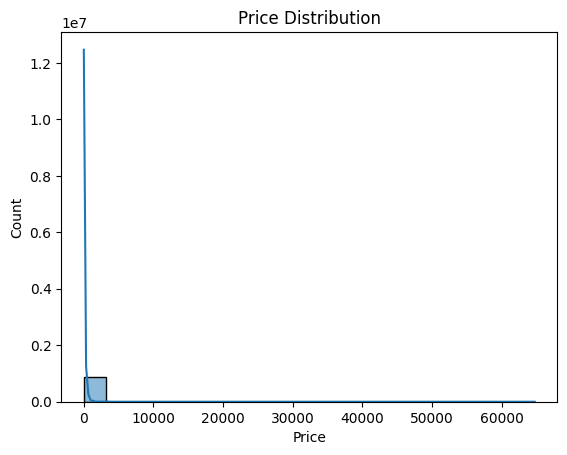

Skewness: 73.30785861024539


count   884964.00
mean       146.32
std        296.79
min          0.22
25%         26.46
50%         65.71
75%        190.49
max      64771.06
Name: price, dtype: float64

In [37]:
sns.histplot(df['price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

print("Skewness:", df['price'].skew())
df['price'].describe()

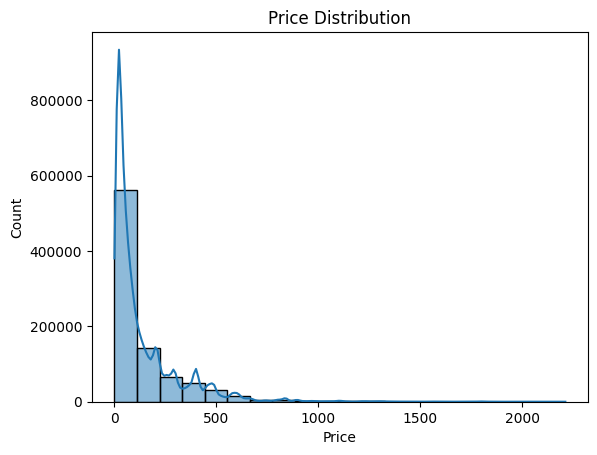

Skewness: 3.068090516110278


count   883821.00
mean       141.24
std        186.37
min          0.22
25%         26.37
50%         65.40
75%        189.65
max       2210.60
Name: price, dtype: float64

In [38]:
sns.histplot(df_no_outliers['price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

print("Skewness:", df_no_outliers['price'].skew())
df_no_outliers['price'].describe()

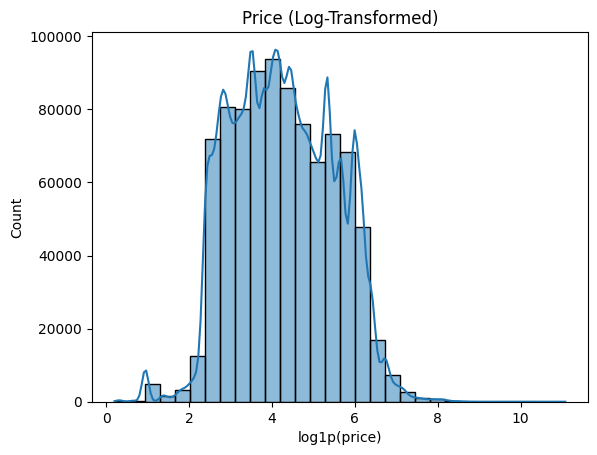

Skewness (log): 0.09847824101566245


count   884964.00
mean         4.27
std          1.22
min          0.20
25%          3.31
50%          4.20
75%          5.25
max         11.08
Name: price_log, dtype: float64

In [39]:
df['price_log'] = np.log1p(df['price'])

sns.histplot(df['price_log'], bins=30, kde=True)
plt.title("Price (Log-Transformed)")
plt.xlabel("log1p(price)")
plt.ylabel("Count")
plt.show()

print("Skewness (log):", df['price_log'].skew())
df['price_log'].describe()

In [40]:
df[df['price'] < 0]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_main,category_sub,category_detail,price_log


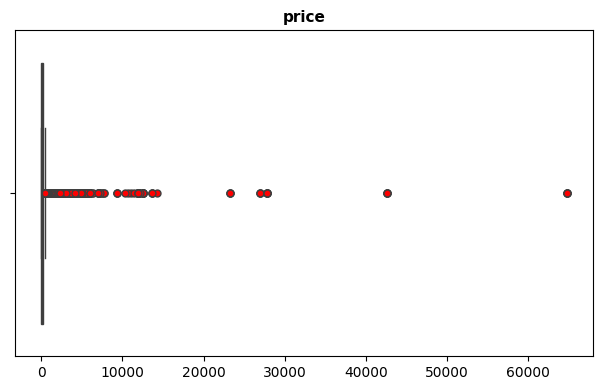

In [41]:
import math

cols = 3
rows = math.ceil(len(num_cols) / cols)

plt.figure(figsize=(18, 4 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)

    sns.boxplot(
        x=df[col],
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markersize=5,
            linestyle='none'
        )
    )

    plt.title(col, fontsize=11, fontweight='bold')
    plt.xlabel("")

plt.tight_layout()
plt.show()

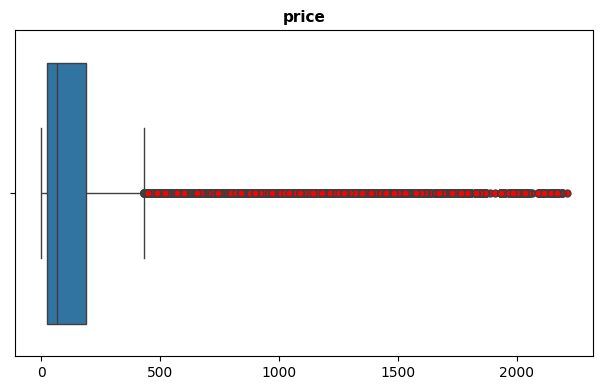

In [42]:
import math

cols = 3
rows = math.ceil(len(num_cols) / cols)

plt.figure(figsize=(18, 4 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)

    sns.boxplot(
        x=df_no_outliers[col],
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markersize=5,
            linestyle='none'
        )
    )

    plt.title(col, fontsize=11, fontweight='bold')
    plt.xlabel("")

plt.tight_layout()
plt.show()

In [43]:
average_price = df.groupby('category_main',dropna=False)['price'].mean()
average_price.sort_values(ascending=False)

category_main
country_yard    352.62
sport           298.06
computers       224.53
kids            198.58
appliances      150.49
electronics     126.74
auto            115.25
construction    101.44
uncategorized    83.01
accessories      53.88
stationery       50.25
medicine         39.50
jewelry          29.57
furniture        21.58
apparel          10.62
Name: price, dtype: float64

In [44]:
average_price = df_no_outliers.groupby('category_main',dropna=False)['price'].mean()
average_price.sort_values(ascending=False)

category_main
country_yard    352.62
sport           298.06
computers       217.68
kids            198.58
appliances      149.73
electronics     118.60
auto            114.93
construction    101.44
uncategorized    79.36
accessories      53.88
stationery       50.25
medicine         39.50
jewelry          29.57
furniture        21.58
apparel          10.62
Name: price, dtype: float64

In [45]:
average_price = df.groupby('category_sub',dropna=False)['price'].mean()
average_price.sort_values(ascending=False)

category_sub
cultivator        429.08
video             365.11
skates            334.85
bicycle           298.06
camera            286.38
network           275.27
lawn_mower        273.12
components        271.74
sewing_machine    233.77
ebooks            190.31
peripherals       159.98
environment       150.34
kitchen           143.73
fax               122.31
steam_cleaner     117.19
accessories       115.25
desktop           103.72
audio             102.15
tablet            101.23
tools             100.05
bedroom            89.33
bathroom           85.82
NaN                83.01
notebook           77.56
iron               75.75
clocks             75.14
telephone          74.46
stapler            54.61
bag                54.15
cartrige           52.69
personal           48.63
toys               46.83
souvenir           33.11
watering           27.10
weather_station    25.55
paper              24.77
calculator         22.91
living_room        20.16
battery            16.77
briefcase   

We found no minus in price, other price will not be considered outliers because it represent real amount.

In [46]:
df[['category_code','category_main','category_sub','category_detail']]

,category_code,category_main,category_sub,category_detail
0,electronics.telephone,electronics,telephone,None
1,computers.components.cooler,computers,components,cooler
2,uncategorized,uncategorized,None,None
3,computers.peripherals.printer,computers,peripherals,printer
4,uncategorized,uncategorized,None,None
...,...,...,...,...
885124,uncategorized,uncategorized,None,None
885125,electronics.video.tv,electronics,video,tv
885126,electronics.clocks,electronics,clocks,None
885127,electronics.telephone,electronics,telephone,None


# Feature Engineering


In [47]:
# make flag for event_type
df['is_view'] = (df['event_type'] == 'view').astype(int)
df['is_cart'] = (df['event_type'] == 'cart').astype(int)
df['is_purchase'] = (df['event_type'] == 'purchase').astype(int)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_main,category_sub,category_detail,price_log,is_view,is_cart,is_purchase
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,no brand,31.90,1515915625519388267,LJuJVLEjPT,electronics,telephone,None,3.49,1,0,0
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,computers,components,cooler,2.90,1,0,0
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,uncategorized,no brand,9.81,1515915625513238515,4TMArHtXQy,uncategorized,None,None,2.38,1,0,0
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,computers,peripherals,printer,4.74,1,0,0
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,uncategorized,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ,uncategorized,None,None,2.83,1,0,0


In [48]:
df[['event_type','is_view','is_cart','is_purchase']]

,event_type,is_view,is_cart,is_purchase
0,view,1,0,0
1,view,1,0,0
2,view,1,0,0
3,view,1,0,0
4,view,1,0,0
...,...,...,...,...
885124,view,1,0,0
885125,view,1,0,0
885126,view,1,0,0
885127,view,1,0,0


In [49]:
# make revenue column
df['sales'] = df.apply(lambda x: x['price'] if x['event_type'] == 'purchase' else 0, axis=1)
df[df['event_type'] == 'purchase']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_main,category_sub,category_detail,price_log,is_view,is_cart,is_purchase,sales
45,2020-09-24 12:04:10+00:00,purchase,1507291,2144415926806642904,computers.components.power_supply,supermicro,217.57,1515915625519390468,xn6SHCnZtk,computers,components,power_supply,5.39,0,0,1,217.57
82,2020-09-24 12:15:06+00:00,purchase,822426,2144415922360680550,computers.peripherals.camera,logitech,123.35,1515915625513574486,2gngxS29Ts,computers,peripherals,camera,4.82,0,0,1,123.35
100,2020-09-24 12:19:01+00:00,purchase,4060928,2144415927049912542,electronics.video.tv,no brand,89.22,1515915625518130982,3yFCkx2KKW,electronics,video,tv,4.50,0,0,1,89.22
132,2020-09-24 12:25:18+00:00,purchase,4060928,2144415927049912542,electronics.video.tv,no brand,89.22,1515915625518130982,3yFCkx2KKW,electronics,video,tv,4.50,0,0,1,89.22
150,2020-09-24 12:29:49+00:00,purchase,1283197,2144415973413749245,computers.peripherals.nas,zyxel,123.79,1515915625519356010,3jFpdbozOd,computers,peripherals,nas,4.83,0,0,1,123.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885070,2021-02-28 23:16:45+00:00,purchase,4154620,2144415922427789416,computers.components.videocards,msi,656.63,1515915625596749373,h4fcX0qpOc,computers,components,videocards,6.49,0,0,1,656.63
885078,2021-02-28 23:20:48+00:00,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN,computers,peripherals,printer,4.22,0,0,1,67.00
885082,2021-02-28 23:23:11+00:00,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN,computers,peripherals,printer,4.22,0,0,1,67.00
885090,2021-02-28 23:26:07+00:00,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN,computers,peripherals,printer,4.22,0,0,1,67.00


In [50]:
df_sales = df[['price','event_type','sales']]
df_sales[df_sales['event_type']=='purchase']

,price,event_type,sales
45,217.57,purchase,217.57
82,123.35,purchase,123.35
100,89.22,purchase,89.22
132,89.22,purchase,89.22
150,123.79,purchase,123.79
...,...,...,...
885070,656.63,purchase,656.63
885078,67.00,purchase,67.00
885082,67.00,purchase,67.00
885090,67.00,purchase,67.00


In [51]:
df_purchase = df[df['event_type'] == 'purchase']
df_purchase.groupby('category_main',dropna=False)['sales'].sum().sort_values(ascending=False)


category_main
computers       3728835.55
uncategorized    493933.32
electronics      450348.57
auto             117557.83
stationery       109670.38
construction     108682.40
appliances       105299.99
country_yard       4339.47
furniture          2090.82
accessories        2084.41
sport              1706.40
medicine            454.00
kids                322.38
jewelry              70.10
Name: sales, dtype: float64

In [52]:
df_purchase.groupby('brand',dropna=False)['sales'].sum().sort_values(ascending=False).head(10)


brand
msi          643492.34
no brand     594729.99
gigabyte     556183.04
palit        484210.58
asus         330147.11
sapphire     306192.94
amd          191987.40
canon        137964.79
powercolor    98804.38
epson         98262.95
Name: sales, dtype: float64

In [53]:
df_purchase.groupby(['category_main','category_sub'],dropna=False)['sales'].sum().sort_index(ascending=False)

category_main  category_sub   
uncategorized  NaN                493933.32
stationery     stapler              3257.81
               paper                2509.95
               cartrige           103595.99
               battery               306.63
sport          bicycle              1706.40
medicine       tools                 454.00
kids           toys                  322.38
jewelry        souvenir               70.10
furniture      living_room          2090.82
electronics    video              112201.02
               telephone          150915.69
               tablet              53347.43
               clocks               1004.88
               camera              20560.16
               calculator            244.43
               audio              112074.96
country_yard   weather_station       163.68
               lawn_mower           1011.75
               cultivator           3164.04
construction   tools              108682.40
computers      peripherals        545462.95
 

In [54]:
df.describe()

,price,price_log,is_view,is_cart,is_purchase,sales
count,884964.00,884964.00,884964.00,884964.00,884964.00,884964.00
mean,146.32,4.27,0.90,0.06,0.04,5.79
std,296.79,1.22,0.30,0.24,0.20,44.50
min,0.22,0.20,0.00,0.00,0.00,0.00
25%,26.46,3.31,1.00,0.00,0.00,0.00
50%,65.71,4.20,1.00,0.00,0.00,0.00
75%,190.49,5.25,1.00,0.00,0.00,0.00
max,64771.06,11.08,1.00,1.00,1.00,3717.65


# EDA

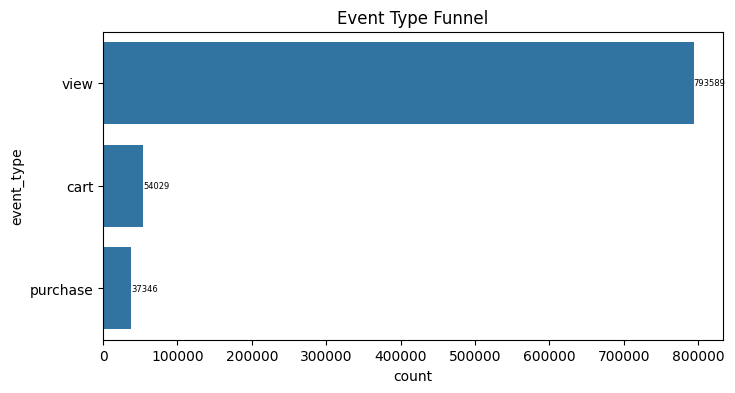

In [55]:
# Create the horizontal countplot
order = df['event_type'].value_counts().index
plt.figure(figsize=(8, 4)) # Optional: adjust figure size
ax = sns.countplot(data=df, y='event_type', order=order) 
for container in ax.containers: #mengeluarkan label pada chart
        ax.bar_label(container, fontsize=6)
plt.title('Event Type Funnel')
plt.show()

In [56]:
df.select_dtypes(include="number").columns

Index(['price', 'price_log', 'is_view', 'is_cart', 'is_purchase', 'sales'], dtype='object')

In [57]:
num_cols = df.select_dtypes(include="number").columns

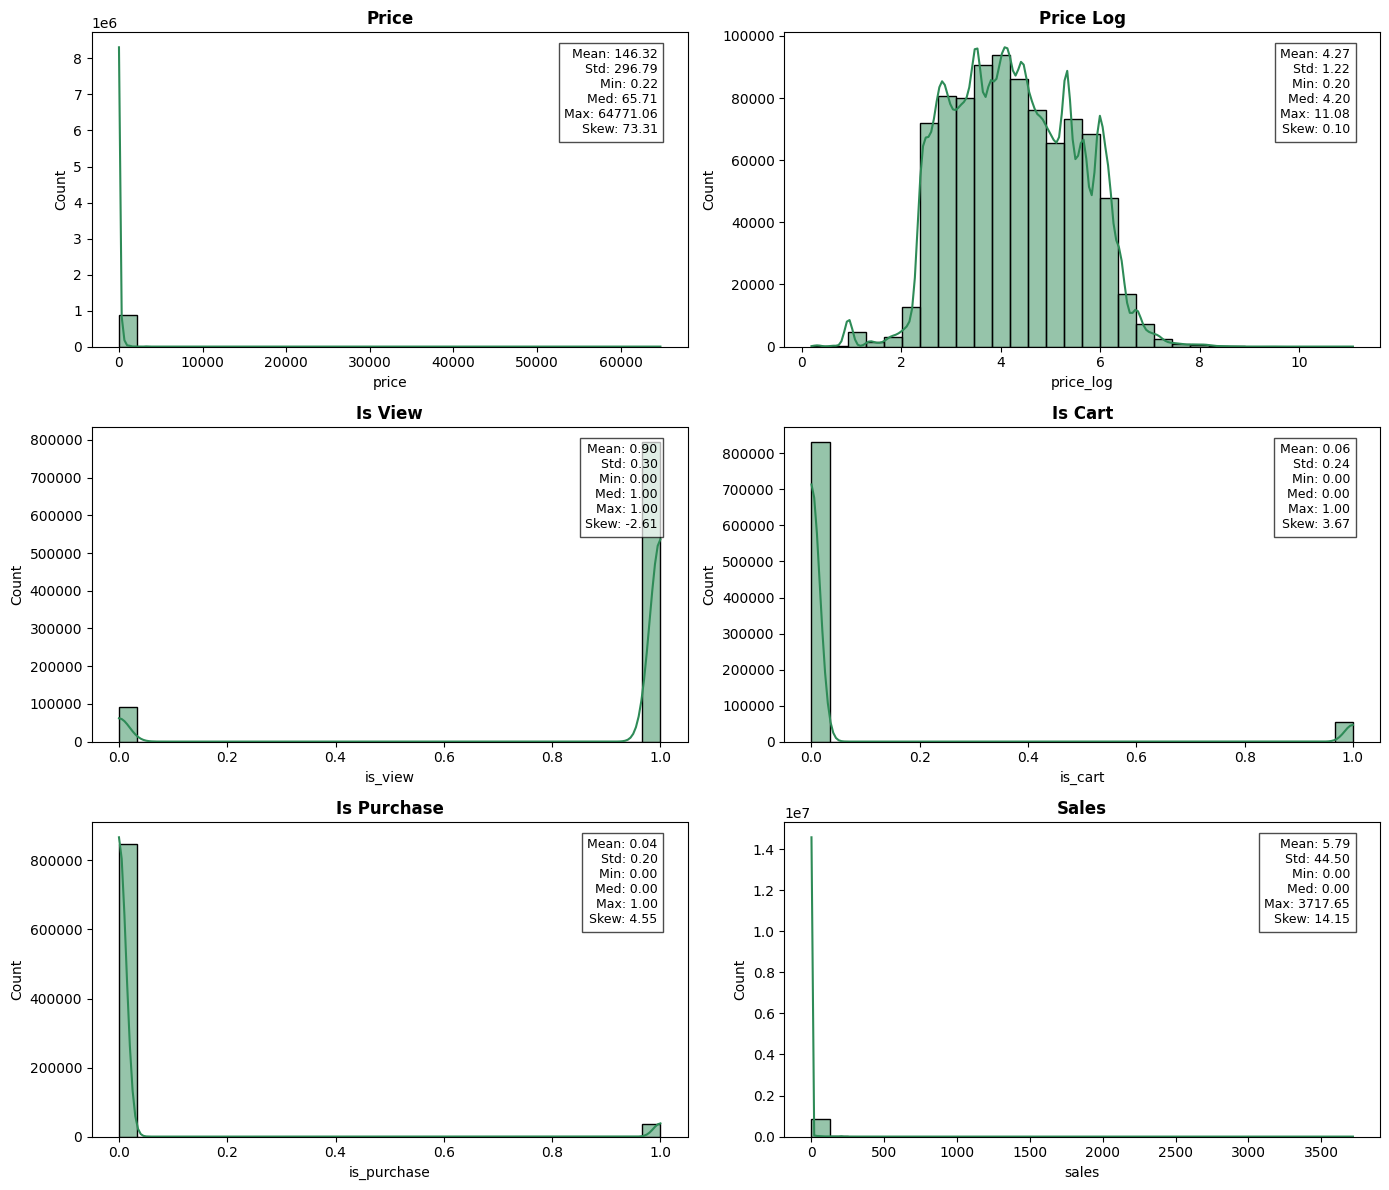

In [58]:
plt.figure(figsize=(14,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    

    sns.histplot(df[col], kde=True, bins=30, color='seagreen')
        
        # memasukan statistik deskriptif
    mean_val = df[col].mean()
    std_val = df[col].std()
    med_val = df[col].median()
    min_val = df[col].min()
    max_val = df[col].max()
    skew_val = df[col].skew()
        
        # memunculkan teks gambaran statistik deskriptif
    text_stats = (
        f"Mean: {mean_val:.2f}\n"
        f"Std: {std_val:.2f}\n"
        f"Min: {min_val:.2f}\n"
        f"Med: {med_val:.2f}\n"
        f"Max: {max_val:.2f}\n"
        f"Skew: {skew_val:.2f}"
        )
    plt.text(0.95, 0.95, text_stats, # memunculkan text box
            ha='right', va='top', transform=plt.gca().transAxes, # merubah koordinat text box menjadi milik chart
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7)) # merancang text box agar mudah dilihat (opacity dll.)
        
    plt.title(col.replace('_', ' ').title(), fontweight='bold')
    plt.tight_layout()

plt.show()

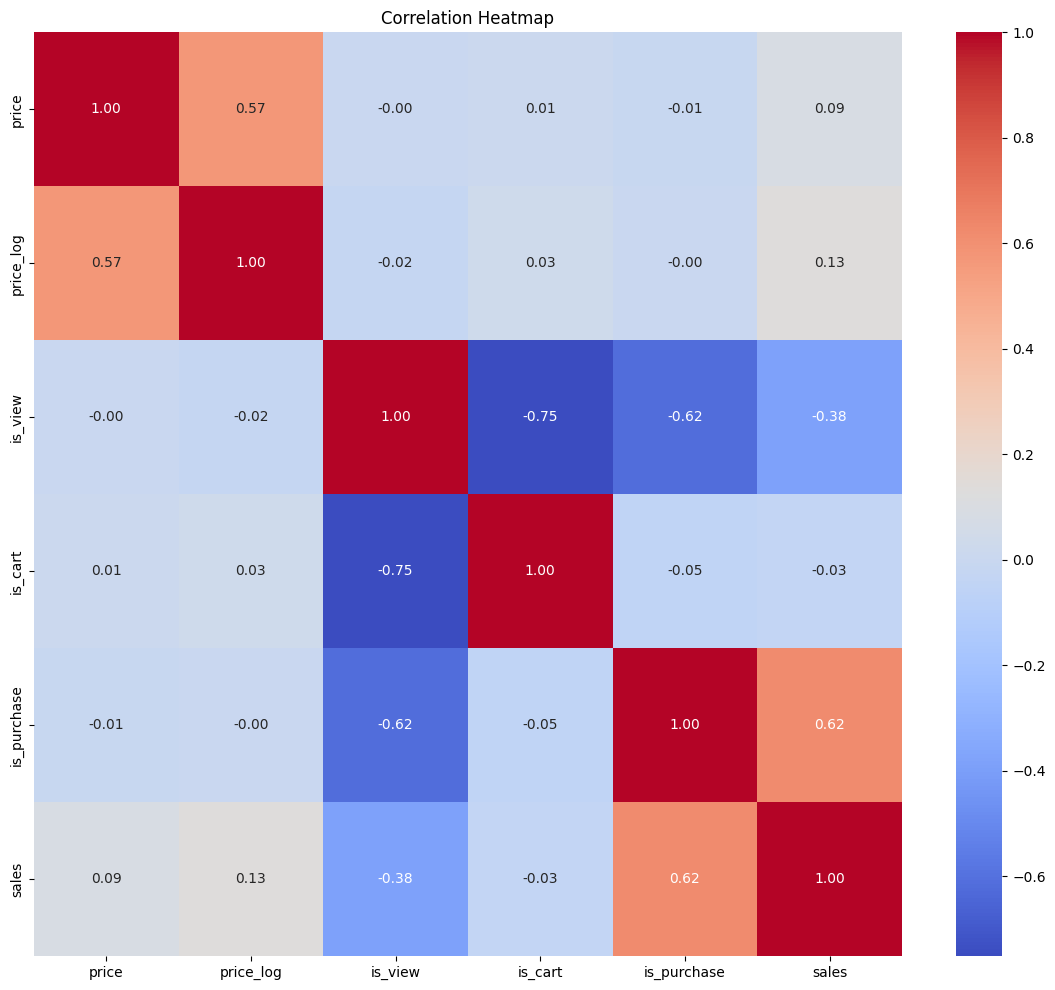

In [59]:
num_cols = df.select_dtypes(include='number')
corr = num_cols.corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [60]:
total_sessions = df['user_session'].count()
purchase_sessions = df['is_purchase'].sum() # all events are purchases

conversion_rate = purchase_sessions / total_sessions
print("Conversion Rate:", conversion_rate)

Conversion Rate: 0.042200586690532046


In [61]:
purchase = df['is_purchase']
purchase.sum()

np.int64(37346)

In [62]:
total_revenue = df['sales'].sum()
total_orders = df['is_purchase'].sum()

AOV = total_revenue / total_orders
print(f'AOV:${AOV:.2f}')

AOV:$137.24


In [63]:
purchase_per_user = df.groupby('user_id')['user_session'].nunique()
returning_users = purchase_per_user[purchase_per_user > 1].count()
total_users = df['user_id'].nunique()

RCR = returning_users / total_users
RCR

np.float64(0.12854185646196195)

In [64]:
avg_purchase_freq = total_orders / total_users
CLV = AOV * avg_purchase_freq
CLV

np.float64(12.585780810682724)

In [65]:
session_summary = df.groupby('user_session').agg({
    'product_id':'count',
    'price':'sum',
    'category_id':'nunique'
}).reset_index()
session_summary.rename(columns={
    'product_id':'items_per_session',
    'price':'session_revenue',
    'category_id':'unique_categories'
}, inplace=True)


In [66]:
session_summary

,user_session,items_per_session,session_revenue,unique_categories
0,000AMhYaQu,1,12.06,1
1,000c34fa-991f-442a-8e07-8c472269bec6,1,421.22,1
2,001HttdHUk,1,61.98,1
3,001P7lK0Pt,2,167.70,1
4,001RxUtFJa,1,104.21,1
...,...,...,...,...
490393,zzxngTdVaG,1,13.17,1
490394,zzy0qXtxYX,1,355.35,1
490395,zzy6W7KylP,1,77.73,1
490396,zzzKOuAubK,2,794.96,1


In [67]:
customer = df.groupby('user_id').agg({
    'product_id':'count',
    'price':'sum',
    'category_id':'nunique',
    'event_time':['min', 'max']
})

customer

product_id   price category_id                event_time  \
                         count     sum     nunique                       min   
user_id                                                                        
1515915625353226922          1   76.48           1 2020-10-29 11:28:35+00:00   
1515915625353230067          1   28.98           1 2020-10-06 06:30:32+00:00   
1515915625353230683         13  814.93           2 2020-11-09 08:52:51+00:00   
1515915625353230922          1  274.40           1 2020-10-02 08:23:40+00:00   
1515915625353234047         36 5481.90           3 2020-09-29 16:01:54+00:00   
...                        ...     ...         ...                       ...   
1515915625611023671          1   32.22           1 2021-02-28 23:54:18+00:00   
1515915625611023730          1  219.94           1 2021-02-28 23:55:01+00:00   
1515915625611024014          1   80.03           1 2021-02-28 23:58:05+00:00   
1515915625611024020          1   64.92           1 2021-02-28 23:58:09+00:00   
1515915625611024030          1   10.16           1 2021-02-28 23:58:14+00:00   

                                               
                                          max  
user_id                                        
1515915625353226922 2020-10-29 11:28:35+00:00  
1515915625353230067 2020-10-06 06:30:32+00:00  
1515915625353230683 2020-12-12 10:33:09+00:00  
1515915625353230922 2020-10-02 08:23:40+00:00  
1515915625353234047 2021-02-18 09:11:44+00:00  
...                                       ...  
1515915625611023671 2021-02-28 23:54:18+00:00  
1515915625611023730 2021-02-28 23:55:01+00:00  
1515915625611024014 2021-02-28 23:58:05+00:00  
1515915625611024020 2021-02-28 23:58:09+00:00  
1515915625611024030 2021-02-28 23:58:14+00:00  

[407237 rows x 5 columns]

In [68]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_main,category_sub,category_detail,price_log,is_view,is_cart,is_purchase,sales
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,no brand,31.90,1515915625519388267,LJuJVLEjPT,electronics,telephone,None,3.49,1,0,0,0.00
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,computers,components,cooler,2.90,1,0,0,0.00
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,uncategorized,no brand,9.81,1515915625513238515,4TMArHtXQy,uncategorized,None,None,2.38,1,0,0,0.00
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,computers,peripherals,printer,4.74,1,0,0,0.00
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,uncategorized,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ,uncategorized,None,None,2.83,1,0,0,0.00


In [69]:
# df.to_csv(r'C:\Users\ASUS\Downloads\latihan Netflix\Rees46 E-Commerce.csv')

In [70]:
category_funnel = df.pivot_table(
    index='category_code',
    columns='event_type',
    values='user_id',
    aggfunc='count',
    fill_value=0
).reset_index()

category_funnel['view_to_cart_rate'] = category_funnel['cart'] / category_funnel['view']
category_funnel['cart_to_purchase_rate'] = category_funnel['purchase'] / category_funnel['cart']

category_funnel.head().sort_values(by='view',ascending=False)

event_type,category_code,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate
0,accessories.bag,64,56,1947,0.03,0.88
3,appliances.environment.air_heater,29,19,840,0.03,0.66
2,apparel.glove,1,0,117,0.01,0.00
4,appliances.environment.fan,1,0,78,0.01,0.00
1,accessories.briefcase,2,0,11,0.18,0.00


In [71]:
bins = [0, 10, 25, 50, 100, 200, 500, 10000]
labels = ["0–10","10–25","25–50","50–100","100–200","200–500","500+"]

df['price_band'] = pd.cut(df['price'], bins=bins, labels=labels)

In [72]:
price_funnel = df.pivot_table(
    index='price_band',
    columns='event_type',
    values='user_id',
    aggfunc='count',
    fill_value=0
).reset_index()

price_funnel['view_to_cart_rate'] = price_funnel['cart'] / price_funnel['view']
price_funnel['cart_to_purchase_rate'] = price_funnel['purchase'] / price_funnel['cart']

price_funnel

event_type,price_band,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate
0,0–10,1830,1483,24457,0.07,0.81
1,10–25,9128,7273,166742,0.05,0.80
2,25–50,9166,7219,140580,0.07,0.79
3,50–100,9246,6429,156398,0.06,0.70
4,100–200,7777,5355,118891,0.07,0.69
5,200–500,14313,8166,150101,0.10,0.57
6,500+,2569,1421,36374,0.07,0.55


In [73]:
session_activity = df.groupby(['user_session','event_type'])['product_id'].count().unstack(fill_value=0).reset_index()

In [74]:
session_activity.head()

event_type,user_session,cart,purchase,view
0,000AMhYaQu,0,0,1
1,000c34fa-991f-442a-8e07-8c472269bec6,0,0,1
2,001HttdHUk,0,0,1
3,001P7lK0Pt,0,0,2
4,001RxUtFJa,0,0,1


In [75]:
session_activity['multi_view_no_cart'] = (
    (session_activity['view'] >= 3) & (session_activity['cart'] == 0)
)

session_activity['multi_view_no_cart'].mean()  # percentage of such sessions

np.float64(0.0774330237888409)

In [76]:
funnel = df.pivot_table(
    index=['user_id', 'user_session', 'product_id'],
    columns='event_type',
    values='event_time',
    aggfunc='count',
    fill_value=0
).reset_index()

In [77]:
funnel = funnel.rename(columns={
    'view': 'views',
    'cart': 'carts',
    'purchase': 'purchases'
})

In [78]:
time_df = df.groupby(['user_id','user_session','product_id'])['event_time'] \
            .agg(['min','max']).reset_index()

time_df['time_spent_sec'] = (time_df['max'] - time_df['min']).dt.total_seconds()

funnel = funnel.merge(time_df[['user_id','user_session','product_id','time_spent_sec']],
                      on=['user_id','user_session','product_id'],
                      how='left')

In [79]:
product_info = df.drop_duplicates('product_id')[['product_id','price','category_main']]
funnel = funnel.merge(product_info, on='product_id', how='left')

In [80]:
funnel['cart_flag'] = (funnel['carts'] > 0).astype(int)

In [81]:
funn_corr = funnel[['views','time_spent_sec','price','cart_flag']].corr()

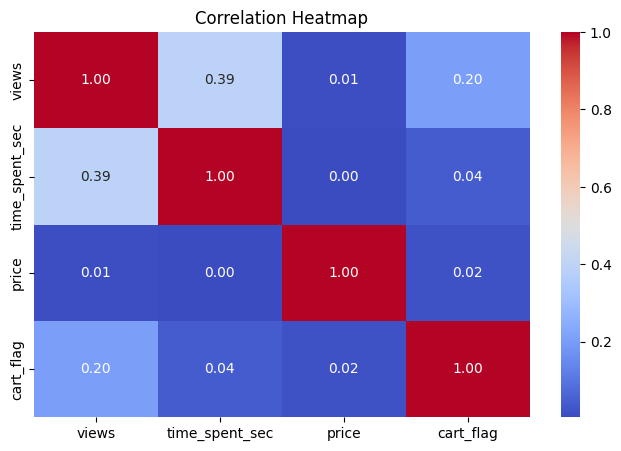

In [82]:

plt.figure(figsize=(8,5))
sns.heatmap(funn_corr, annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

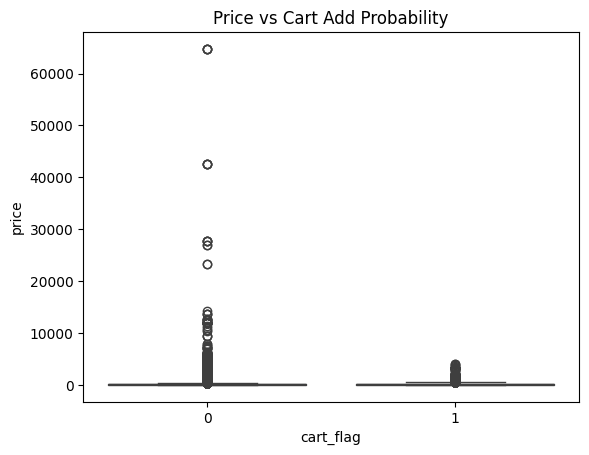

In [83]:
sns.boxplot(data=funnel, x='cart_flag', y='price')
plt.title("Price vs Cart Add Probability")
plt.show()

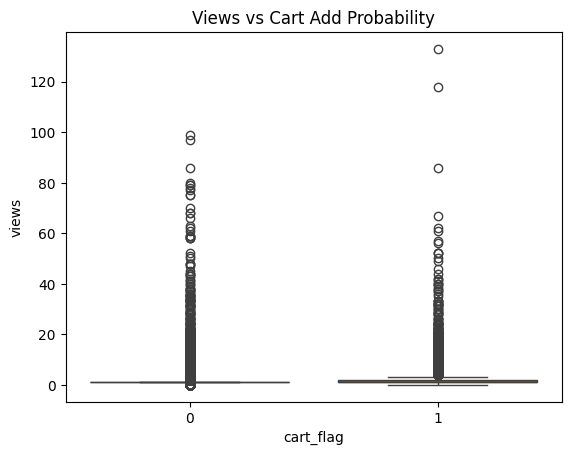

In [84]:
sns.boxplot(data=funnel, x='cart_flag', y='views')
plt.title("Views vs Cart Add Probability")
plt.show()

In [85]:
category_cart_rate = funnel.groupby('category_main')['cart_flag'].mean().sort_values(ascending=False)
print(category_cart_rate)

category_main
computers       0.12
stationery      0.10
sport           0.08
electronics     0.06
furniture       0.06
construction    0.05
jewelry         0.05
uncategorized   0.05
auto            0.05
kids            0.04
accessories     0.04
appliances      0.03
medicine        0.03
country_yard    0.02
apparel         0.01
Name: cart_flag, dtype: float64


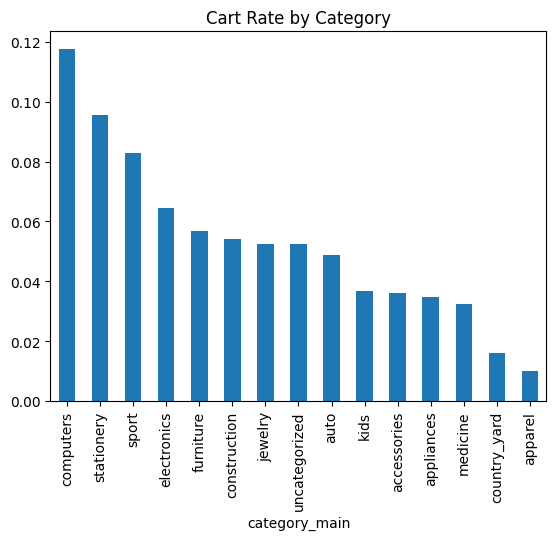

In [86]:
category_cart_rate.plot(kind='bar')
plt.title("Cart Rate by Category")
plt.show()

# Session Level


## Price Sensitivity

In [87]:
# Binning prices to see conversion by price range
df_no_outliers['price_bin'] = pd.qcut(df_no_outliers['price'], q=6)

price_analysis = df_no_outliers.groupby('price_bin')['event_type'].value_counts().unstack().fillna(0)
price_analysis['conversion_rate'] = (price_analysis['purchase'] / price_analysis['view']) * 100

print(price_analysis[['view', 'purchase', 'conversion_rate']])

event_type          view  purchase  conversion_rate
price_bin                                          
(0.219, 18.4]     133956      5975             4.46
(18.4, 35.57]     131085      7244             5.53
(35.57, 65.4]     134105      5639             4.20
(65.4, 126.68]    134094      5568             4.15
(126.68, 271.63]  129598      6675             5.15
(271.63, 2210.6]  129639      6238             4.81


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17716\481894194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['price_bin'] = pd.qcut(df_no_outliers['price'], q=6)


## Session Engagement

In [88]:
# Aggregate by session using built-in string aliases
session_activity = df.groupby('user_session').agg(
    total_views=('is_view', 'sum'),
    purchased=('is_purchase', 'max')  # 1 if any purchase happened, 0 otherwise
).reset_index()

# Calculate average views for buyers vs non-buyers
# We can use a simple groupby on the resulting boolean/int column
comparison = session_activity.groupby('purchased')['total_views'].mean()

print(comparison)

purchased
0   1.53
1   3.33
Name: total_views, dtype: float64


### for Tableau


In [89]:
# Convert event_time to datetime and extract date
df['event_time'] = pd.to_datetime(df['event_time'])
df['date'] = df['event_time'].dt.date

# Create the master aggregation
tableau_df = df.groupby(['date', 'category_main', 'brand', 'event_type']).agg(
    total_events=('user_id', 'count'),
    unique_users=('user_id', 'nunique'),
    avg_price=('price', 'mean')
).reset_index()

tableau_df
# Export to CSV
# tableau_df.to_csv('ecommerce_analysis_summary.csv', index=False)

,date,category_main,brand,event_type,total_events,unique_users,avg_price
0,2020-09-24,accessories,dell,view,1,1,61.46
1,2020-09-24,accessories,hama,view,3,1,20.00
2,2020-09-24,accessories,i-blason,view,1,1,15.70
3,2020-09-24,accessories,romix,view,1,1,21.59
4,2020-09-24,accessories,xiaomi,view,1,1,59.83
...,...,...,...,...,...,...,...
120451,2021-02-28,uncategorized,zalman,cart,1,1,43.48
120452,2021-02-28,uncategorized,zalman,view,14,13,52.87
120453,2021-02-28,uncategorized,zebra,view,3,3,10.10
120454,2021-02-28,uncategorized,zetton,view,1,1,18.57


## Higher Price vs Session Duration

In [90]:
df_1 = df.sort_values(['user_session', 'event_time'])
df_1

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_main,category_sub,category_detail,price_log,is_view,is_cart,is_purchase,sales,price_band,date
717617,2021-01-31 20:27:14+00:00,view,337112,2144415921505042512,uncategorized,no brand,12.06,1515915625599214495,000AMhYaQu,uncategorized,None,None,2.57,1,0,0,0.00,10–25,2021-01-31
27197,2020-09-30 17:52:02+00:00,view,1675002,2144415922872385653,electronics.tablet,xiaomi,421.22,1515915625509232600,000c34fa-991f-442a-8e07-8c472269bec6,electronics,tablet,None,6.05,1,0,0,0.00,200–500,2020-09-30
577627,2021-01-09 23:35:49+00:00,view,40146,2144415925732901052,appliances.kitchen.juicer,no brand,61.98,1515915625591270059,001HttdHUk,appliances,kitchen,juicer,4.14,1,0,0,0.00,50–100,2021-01-09
221736,2020-11-06 01:25:30+00:00,view,3605162,2144415924684325027,electronics.audio.headphone,no brand,18.86,1515915625536141302,001P7lK0Pt,electronics,audio,headphone,2.99,1,0,0,0.00,10–25,2020-11-06
221737,2020-11-06 01:25:43+00:00,view,3585175,2144415924684325027,electronics.audio.headphone,samsung,148.84,1515915625536141302,001P7lK0Pt,electronics,audio,headphone,5.01,1,0,0,0.00,100–200,2020-11-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238596,2020-11-08 17:08:01+00:00,view,547414,2144415924491387038,computers.components.motherboard,asus,355.35,1515915625537123090,zzy0qXtxYX,computers,components,motherboard,5.88,1,0,0,0.00,200–500,2020-11-08
510286,2020-12-27 11:51:44+00:00,view,136700,2144415924491387038,computers.components.motherboard,asrock,77.73,1515915625569509758,zzy6W7KylP,computers,components,motherboard,4.37,1,0,0,0.00,50–100,2020-12-27
673751,2021-01-24 18:38:37+00:00,view,1821813,2144415922427789416,computers.components.videocards,no brand,397.48,1515915625596696518,zzzKOuAubK,computers,components,videocards,5.99,1,0,0,0.00,200–500,2021-01-24
673759,2021-01-24 18:40:01+00:00,view,1821813,2144415922427789416,computers.components.videocards,no brand,397.48,1515915625596696518,zzzKOuAubK,computers,components,videocards,5.99,1,0,0,0.00,200–500,2021-01-24


In [91]:
# Aggregate by session
session_stats = df.groupby('user_session').agg(
    start_time=('event_time', 'min'),
    end_time=('event_time', 'max'),
    avg_price=('price', 'mean'),
    max_price=('price', 'max'),
    event_count=('event_type', 'count')
)

# Calculate duration in seconds
session_stats['duration_seconds'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds()

# Filter out "single-hit" sessions (duration = 0) to avoid skewing results
session_stats = session_stats[session_stats['duration_seconds'] > 0]

In [92]:
session_stats

,start_time,end_time,avg_price,max_price,event_count,duration_seconds
user_session,,,,,,
001P7lK0Pt,2020-11-06 01:25:30+00:00,2020-11-06 01:25:43+00:00,83.85,148.84,2,13.00
003pEktS1X,2020-11-02 18:11:24+00:00,2020-11-02 18:12:33+00:00,12.95,16.05,2,69.00
005wDfXQrv,2020-11-06 04:40:04+00:00,2020-11-06 04:40:50+00:00,35.08,35.08,2,46.00
00735945-0395-48db-967c-59418c0ddb89,2020-11-25 13:48:15+00:00,2020-11-25 13:50:01+00:00,70.00,70.00,2,106.00
009zFA5YxX,2021-02-26 06:34:36+00:00,2021-02-26 07:05:00+00:00,921.71,1385.10,8,1824.00
...,...,...,...,...,...,...
zztRHEozV0,2020-09-30 12:31:41+00:00,2020-09-30 12:32:30+00:00,196.23,214.10,3,49.00
zztce59nU2,2020-10-29 18:02:28+00:00,2020-10-29 18:56:15+00:00,15.08,15.08,9,3227.00
zzveLpjyyb,2021-02-15 20:06:01+00:00,2021-02-15 20:10:44+00:00,9.40,9.40,5,283.00


In [93]:
correlation = session_stats['avg_price'].corr(session_stats['duration_seconds'])
print(f"Correlation between Average Price and Session Duration: {correlation:.4f}")

Correlation between Average Price and Session Duration: 0.0063


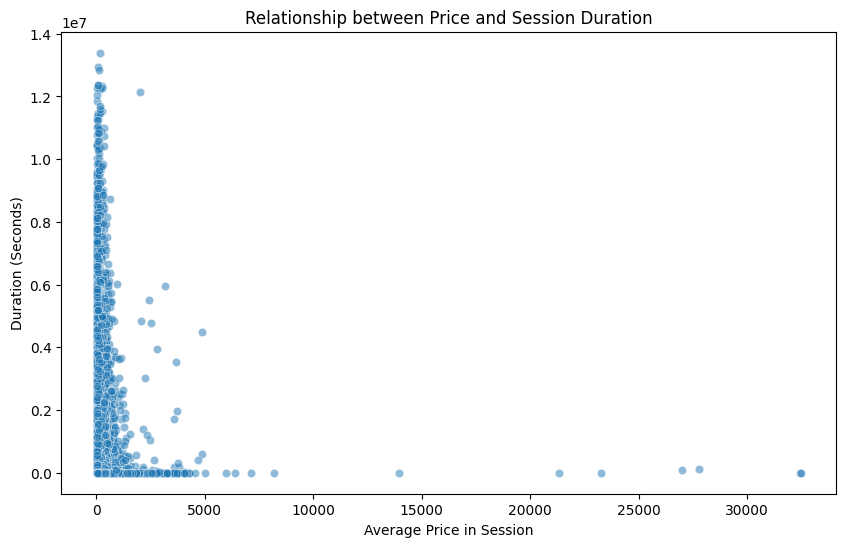

In [94]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=session_stats, x='avg_price', y='duration_seconds', alpha=0.5)
plt.title('Relationship between Price and Session Duration')
plt.xlabel('Average Price in Session')
plt.ylabel('Duration (Seconds)')
plt.show()

In [95]:
# Create price quartiles
session_stats['price_tier'] = pd.qcut(session_stats['avg_price'], q=4, labels=['Budget', 'Economy', 'Mid-Range', 'Luxury'])

# Compare mean durations
tier_analysis = session_stats.groupby('price_tier')['duration_seconds'].mean()
print(tier_analysis)

price_tier
Budget       70891.42
Economy      88072.47
Mid-Range   104369.86
Luxury       89284.76
Name: duration_seconds, dtype: float64


## Session Duration to Cart or Purchase

In [96]:
session_analysis = df.groupby('user_session').agg(
    duration_seconds=('event_time', lambda x: (x.max() - x.min()).total_seconds()),
    made_purchase=('is_purchase', 'max'),
    added_to_cart=('is_cart', 'max')
).reset_index()

# Filter out 0-second sessions (single-page views) for a cleaner analysis
session_analysis = session_analysis[session_analysis['duration_seconds'] > 0]

In [97]:
# Average duration for Purchase vs No Purchase
purchase_diff = session_analysis.groupby('made_purchase')['duration_seconds'].mean()

# Average duration for Cart vs No Cart
cart_diff = session_analysis.groupby('added_to_cart')['duration_seconds'].mean()

print("Average Session Duration (Seconds):")
print(f"Purchased: {purchase_diff[1]:.2f}s vs Not Purchased: {purchase_diff[0]:.2f}s")
print(f"Added to Cart: {cart_diff[1]:.2f}s vs Not Added: {cart_diff[0]:.2f}s")

Average Session Duration (Seconds):
Purchased: 80339.98s vs Not Purchased: 89653.80s
Added to Cart: 73314.58s vs Not Added: 94332.26s


In [98]:
correlation_purchase = session_analysis['duration_seconds'].corr(session_analysis['made_purchase'])
correlation_cart = session_analysis['duration_seconds'].corr(session_analysis['added_to_cart'])

print(f"Correlation (Duration & Purchase): {correlation_purchase:.4f}")
print(f"Correlation (Duration & Cart): {correlation_cart:.4f}")

Correlation (Duration & Purchase): -0.0062
Correlation (Duration & Cart): -0.0173


## Research or not

In [99]:
# 1. Pre-calculate the conversion flag (Vectorized)
df['is_conversion'] = ((df['is_purchase'] == 1) | (df['is_cart'] == 1))

# 2. Get the first conversion time for every session (Vectorized)
# By filtering first, we only process sessions that actually had a conversion
first_conv = df[df['is_conversion']].groupby('user_session')['event_time'].min().rename('first_conversion_time')

# 3. Perform the standard session-level aggregation (Optimized C-engine)
session_research = df.groupby('user_session').agg(
    total_views=('is_view', 'sum'),
    unique_products_viewed=('product_id', 'nunique'),
    is_buyer=('is_purchase', 'max'),
    is_carter=('is_cart', 'max'),
    session_start=('event_time', 'min')
)

# 4. Join the first conversion time back to the session data
session_research = session_research.join(first_conv)

# 5. Calculate duration (Vectorized)
session_research['research_duration_mins'] = (
    (session_research['first_conversion_time'] - session_research['session_start']).dt.total_seconds() / 60
)

# 6. Filter for converters (Fast slice)
converters = session_research[session_research['first_conversion_time'].notna()].copy()

In [100]:
def segment_behavior(row):
    if row['unique_products_viewed'] <= 2 and row['research_duration_mins'] <= 3:
        return 'Decisive/Direct Buyer'
    elif row['unique_products_viewed'] > 5 or row['research_duration_mins'] > 10:
        return 'Deep Researcher'
    else:
        return 'Casual Browser'

converters['shopper_type'] = converters.apply(segment_behavior, axis=1)

# See the distribution
print(converters['shopper_type'].value_counts(normalize=True) * 100)

shopper_type
Decisive/Direct Buyer   62.46
Casual Browser          19.61
Deep Researcher         17.93
Name: proportion, dtype: float64


Correlation between Product Variety and Research Time: 0.0707


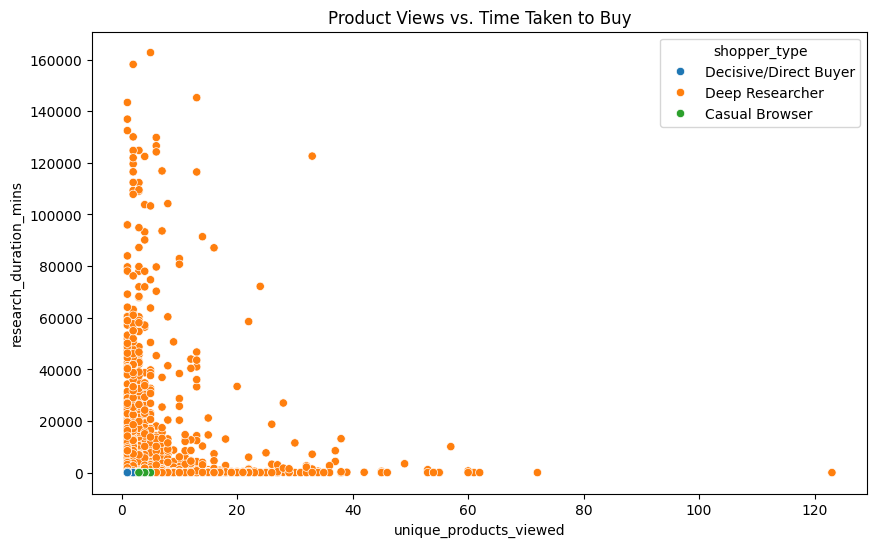

In [101]:
correlation = converters['unique_products_viewed'].corr(converters['research_duration_mins'])
print(f"Correlation between Product Variety and Research Time: {correlation:.4f}")

# Visualize the clusters
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(data=converters, x='unique_products_viewed', y='research_duration_mins', hue='shopper_type')
plt.title('Product Views vs. Time Taken to Buy')
plt.show()

## number of sessions based conversion

In [102]:
# 1. Aggregate by User
user_behavior = df.groupby('user_id').agg(
    total_sessions=('user_session', 'nunique'),
    ever_purchased=('is_purchase', 'max'),
    ever_carted=('is_cart', 'max')
).reset_index()

# 2. Define "Converted" as either a purchase or a cart addition
user_behavior['is_converter'] = ((user_behavior['ever_purchased'] == 1) | 
                                 (user_behavior['ever_carted'] == 1)).astype(int)

In [103]:
# Group by the number of sessions and calculate the mean of 'is_converter'
# This gives us the conversion probability for each session count
conversion_trend = user_behavior.groupby('total_sessions')['is_converter'].mean().reset_index()

# Rename for clarity
conversion_trend.columns = ['number_of_sessions', 'conversion_probability']

print(conversion_trend.head(10))

   number_of_sessions  conversion_probability
0                   1                    0.06
1                   2                    0.24
2                   3                    0.40
3                   4                    0.48
4                   5                    0.53
5                   6                    0.55
6                   7                    0.60
7                   8                    0.60
8                   9                    0.60
9                  10                    0.63


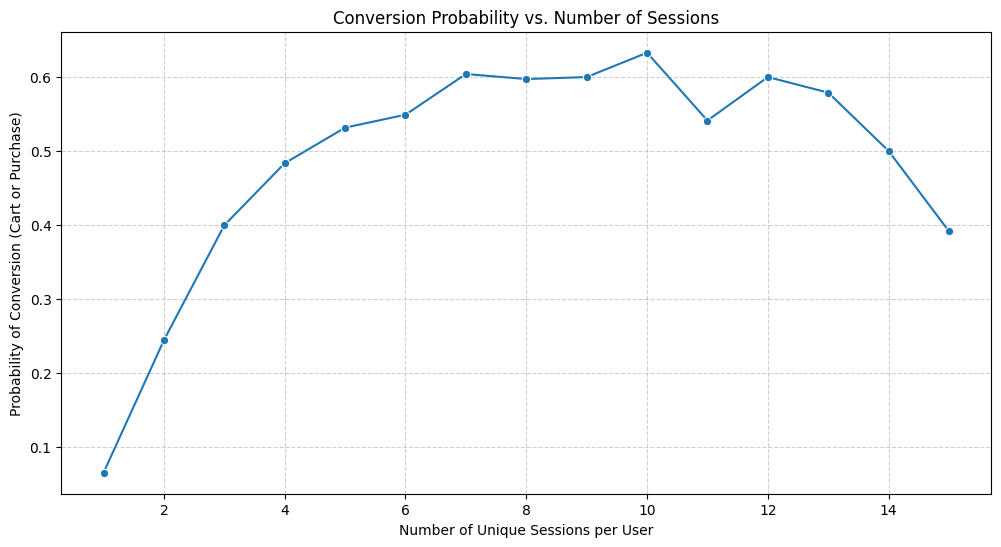

In [104]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=conversion_trend[conversion_trend['number_of_sessions'] <= 15], 
             x='number_of_sessions', y='conversion_probability', marker='o')

plt.title('Conversion Probability vs. Number of Sessions')
plt.xlabel('Number of Unique Sessions per User')
plt.ylabel('Probability of Conversion (Cart or Purchase)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [105]:
correlation = user_behavior['total_sessions'].corr(user_behavior['is_converter'])
print(f"Correlation between Session Count and Conversion: {correlation:.4f}")

Correlation between Session Count and Conversion: 0.1542


In [106]:
def categorize_loyalty(n):
    if n == 1: return 'One-time Visitor'
    if 2 <= n <= 4: return 'Returner'
    return 'Frequent Visitor'

user_behavior['loyalty_segment'] = user_behavior['total_sessions'].apply(categorize_loyalty)
user_behavior

# Export this summary for Tableau
# user_behavior.to_csv('user_loyalty_analysis.csv', index=False)

,user_id,total_sessions,ever_purchased,ever_carted,is_converter,loyalty_segment
0,1515915625353226922,1,0,0,0,One-time Visitor
1,1515915625353230067,1,0,0,0,One-time Visitor
2,1515915625353230683,4,0,0,0,Returner
3,1515915625353230922,1,0,0,0,One-time Visitor
4,1515915625353234047,1,0,0,0,One-time Visitor
...,...,...,...,...,...,...
407232,1515915625611023671,1,0,0,0,One-time Visitor
407233,1515915625611023730,1,0,0,0,One-time Visitor
407234,1515915625611024014,1,0,0,0,One-time Visitor
407235,1515915625611024020,1,0,0,0,One-time Visitor


In [107]:
user_behavior['loyalty_segment'].value_counts()

loyalty_segment
One-time Visitor    354890
Returner             49542
Frequent Visitor      2805
Name: count, dtype: int64

In [108]:
# Create the User Summary
user_summary = df.groupby('user_id').agg(
    total_sessions=('user_session', 'nunique'),
    has_purchased=('is_purchase', 'max'),
    has_carted=('is_cart', 'max'),
    user_total_views=('is_view', 'sum')
).reset_index()

user_summary

# Export both
# df.to_csv('raw_events.csv', index=False)
# user_summary.to_csv('user_summary.csv', index=False)

,user_id,total_sessions,has_purchased,has_carted,user_total_views
0,1515915625353226922,1,0,0,1
1,1515915625353230067,1,0,0,1
2,1515915625353230683,4,0,0,13
3,1515915625353230922,1,0,0,1
4,1515915625353234047,1,0,0,36
...,...,...,...,...,...
407232,1515915625611023671,1,0,0,1
407233,1515915625611023730,1,0,0,1
407234,1515915625611024014,1,0,0,1
407235,1515915625611024020,1,0,0,1


In [109]:
# 1. Identify Conversion Events (Vectorized)
df['is_conversion'] = (df['is_purchase'] == 1) | (df['is_cart'] == 1)
first_conv = df[df['is_conversion']].groupby('user_session')['event_time'].min().rename('first_conv_time')

# 2. Create the Session Master
# We use 'first' for Category/Brand to represent the "Entry Intent" 
# or 'last' if you want the "Final Decision" item.
session_master = df.groupby('user_session').agg(
    user_id=('user_id', 'first'),
    brand=('brand', 'first'),
    category_main=('category_main', 'first'),
    category_sub=('category_sub', 'first'),
    category_detail=('category_detail', 'first'),
    total_views=('is_view', 'sum'),
    purchased=('is_purchase', 'max'),
    added_to_cart=('is_cart', 'max'),
    avg_price=('price', 'mean'),
    session_start=('event_time', 'min'),
    session_end=('event_time', 'max')
).reset_index()

# 3. Join and Calculate Durations
session_master = session_master.join(first_conv, on='user_session')

session_master['total_duration_mins'] = (
    (session_master['session_end'] - session_master['session_start']).dt.total_seconds() / 60
)

session_master

,user_session,user_id,brand,category_main,category_sub,category_detail,total_views,purchased,added_to_cart,avg_price,session_start,session_end,first_conv_time,total_duration_mins
0,000AMhYaQu,1515915625599214495,no brand,uncategorized,None,None,1,0,0,12.06,2021-01-31 20:27:14+00:00,2021-01-31 20:27:14+00:00,NaT,0.00
1,000c34fa-991f-442a-8e07-8c472269bec6,1515915625509232600,xiaomi,electronics,tablet,None,1,0,0,421.22,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,NaT,0.00
2,001HttdHUk,1515915625591270059,no brand,appliances,kitchen,juicer,1,0,0,61.98,2021-01-09 23:35:49+00:00,2021-01-09 23:35:49+00:00,NaT,0.00
3,001P7lK0Pt,1515915625536141302,no brand,electronics,audio,headphone,2,0,0,83.85,2020-11-06 01:25:30+00:00,2020-11-06 01:25:43+00:00,NaT,0.22
4,001RxUtFJa,1515915625570256322,asus,computers,components,videocards,1,0,0,104.21,2020-12-29 04:50:33+00:00,2020-12-29 04:50:33+00:00,NaT,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490393,zzxngTdVaG,1515915625598496842,no brand,uncategorized,None,None,1,0,0,13.17,2021-02-15 13:27:42+00:00,2021-02-15 13:27:42+00:00,NaT,0.00
490394,zzy0qXtxYX,1515915625537123090,asus,computers,components,motherboard,1,0,0,355.35,2020-11-08 17:08:01+00:00,2020-11-08 17:08:01+00:00,NaT,0.00
490395,zzy6W7KylP,1515915625569509758,asrock,computers,components,motherboard,1,0,0,77.73,2020-12-27 11:51:44+00:00,2020-12-27 11:51:44+00:00,NaT,0.00
490396,zzzKOuAubK,1515915625596696518,no brand,computers,components,videocards,2,0,0,397.48,2021-01-24 18:38:37+00:00,2021-01-24 18:40:01+00:00,NaT,1.40


In [110]:
# session_master.to_csv('tableau_ecommerce_master.csv', index=False)

In [111]:
# Check the distribution of session durations
print(session_master['total_duration_mins'].describe())

# Look at the top 10 longest sessions
session_master.sort_values('total_duration_mins', ascending=False).head(10)

count   490398.00
mean       420.46
std       4979.54
min          0.00
25%          0.00
50%          0.00
75%          0.50
max     223240.28
Name: total_duration_mins, dtype: float64


,user_session,user_id,brand,category_main,category_sub,category_detail,total_views,purchased,added_to_cart,avg_price,session_start,session_end,first_conv_time,total_duration_mins
65041,8513e55d-11eb-45b2-bf91-636146a20a08,1515915625353482553,hammer,uncategorized,None,None,99,0,0,168.24,2020-09-25 05:31:46+00:00,2021-02-27 06:12:03+00:00,NaT,223240.28
170996,LSmWtgw04Z,1515915625520863746,multitronics,computers,desktop,tv,12,0,0,87.24,2020-09-29 14:02:11+00:00,2021-02-26 08:14:46+00:00,NaT,215652.58
293459,b1be8fbf-2376-4b27-9702-efd1b8f41e03,1515915625427007765,amd,computers,components,cpu,89,0,0,134.83,2020-09-29 17:06:11+00:00,2021-02-25 05:08:58+00:00,NaT,213842.78
317303,e048d931-ee9c-496c-9715-968169fe595b,1515915625522818719,no brand,computers,peripherals,printer,10,0,1,64.16,2020-10-06 08:03:33+00:00,2021-02-26 09:26:13+00:00,2021-01-27 07:29:20+00:00,206002.67
29427,3f1f38a8-de02-497c-b805-f58056ecf46e,1515915625522818719,no brand,computers,peripherals,printer,4,1,1,68.87,2020-10-06 08:07:27+00:00,2021-02-26 09:27:49+00:00,2020-10-06 08:30:53+00:00,206000.37
9936,1EAsfxkanh,1515915625519906968,pocketbook,computers,ebooks,None,2,0,0,241.57,2020-09-26 07:10:47+00:00,2021-02-16 02:24:15+00:00,NaT,205633.47
37472,4f2794f0-215f-451f-9344-42b4ab4e055d,1515915625369372234,no brand,computers,peripherals,camera,2,0,0,11.29,2020-10-01 10:22:43+00:00,2021-02-20 13:34:23+00:00,NaT,204671.67
285402,a1788ae6-82fd-4a7f-be62-39c7684956fa,1515915625355611972,sony,uncategorized,None,None,40,0,0,240.11,2020-10-07 01:53:24+00:00,2021-02-26 00:02:17+00:00,NaT,204368.88
20954,2bc2f4b2-831e-44f4-bc0e-efabe4ca5253,1515915625353234047,honor,electronics,telephone,headphone,36,0,0,152.27,2020-09-29 16:01:54+00:00,2021-02-18 09:11:44+00:00,NaT,204069.83
285002,Zy61Pjw4WW,1515915625522107572,kyocera,computers,peripherals,printer,3,0,0,2000.65,2020-10-03 18:02:38+00:00,2021-02-21 10:37:57+00:00,NaT,202595.32


In [114]:
session_master[['user_session','user_id','session_start','session_end','total_duration_mins']].sort_values('total_duration_mins', ascending=False).head(10)

,user_session,user_id,session_start,session_end,total_duration_mins
65041,8513e55d-11eb-45b2-bf91-636146a20a08,1515915625353482553,2020-09-25 05:31:46+00:00,2021-02-27 06:12:03+00:00,223240.28
170996,LSmWtgw04Z,1515915625520863746,2020-09-29 14:02:11+00:00,2021-02-26 08:14:46+00:00,215652.58
293459,b1be8fbf-2376-4b27-9702-efd1b8f41e03,1515915625427007765,2020-09-29 17:06:11+00:00,2021-02-25 05:08:58+00:00,213842.78
317303,e048d931-ee9c-496c-9715-968169fe595b,1515915625522818719,2020-10-06 08:03:33+00:00,2021-02-26 09:26:13+00:00,206002.67
29427,3f1f38a8-de02-497c-b805-f58056ecf46e,1515915625522818719,2020-10-06 08:07:27+00:00,2021-02-26 09:27:49+00:00,206000.37
9936,1EAsfxkanh,1515915625519906968,2020-09-26 07:10:47+00:00,2021-02-16 02:24:15+00:00,205633.47
37472,4f2794f0-215f-451f-9344-42b4ab4e055d,1515915625369372234,2020-10-01 10:22:43+00:00,2021-02-20 13:34:23+00:00,204671.67
285402,a1788ae6-82fd-4a7f-be62-39c7684956fa,1515915625355611972,2020-10-07 01:53:24+00:00,2021-02-26 00:02:17+00:00,204368.88
20954,2bc2f4b2-831e-44f4-bc0e-efabe4ca5253,1515915625353234047,2020-09-29 16:01:54+00:00,2021-02-18 09:11:44+00:00,204069.83
285002,Zy61Pjw4WW,1515915625522107572,2020-10-03 18:02:38+00:00,2021-02-21 10:37:57+00:00,202595.32
